<a href="https://colab.research.google.com/github/hxh00138/dominant-process/blob/main/ice_roughness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get update
!apt-get install -y texlive-latex-extra texlive-fonts-recommended cm-super dvipng

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import SparsePCA
from scipy.io import loadmat
import h5py
from scipy import sparse, linalg
from scipy.optimize import curve_fit, root
from scipy.integrate import odeint
from scipy.interpolate import interp1d

import matplotlib as mpl
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')
mpl.rc('figure', figsize=(15, 3))
mpl.rc('xtick', labelsize=14)
mpl.rc('ytick', labelsize=14)
mpl.rc('axes', labelsize=20)
mpl.rc('axes', titlesize=20)
%config InlineBackend.figure_format = 'retina'

from matplotlib.colors import ListedColormap

# Seaborn colormap
import seaborn as sns
sns_list = sns.color_palette('deep').as_hex()
sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)

cm = sns_cmap

mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,244 kB]
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,607 kB]
Get:13 https://r2u.stat.illinois.edu/u

In [4]:
from google.colab import drive
drive.mount('/content/drive')

#path = '/content/drive/MyDrive/Colab Notebooks/burgers_shock.mat'
#path = '/content/drive/MyDrive/dominant_ed1977.mat'

file = h5py.File('/content/drive/MyDrive/dominant_ed1977.mat', 'r')

x = np.array(file['x'])
y = np.array(file['z'])
u = np.array(file['u'])
v = np.array(file['w'])
p = np.array(file['p'])
Ruu = np.array(file['uu'])
Ruv = np.array(file['uw'])
Duu = np.array(file['uud'])
Duv = np.array(file['uwd'])

# data = loadmat(path)
# y = data['z'][:, 0]
# x = data['x'][0, :]
# u = data['u']
# v = data['w']
# p = data['p']
# Ruu = data['uu']
# Ruv = data['uw']
# Duu = data['uud']
# Duv = data['uwd']


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
x = np.squeeze(x)
y = np.squeeze(y)

In [31]:
Ruu.shape

(28672,)

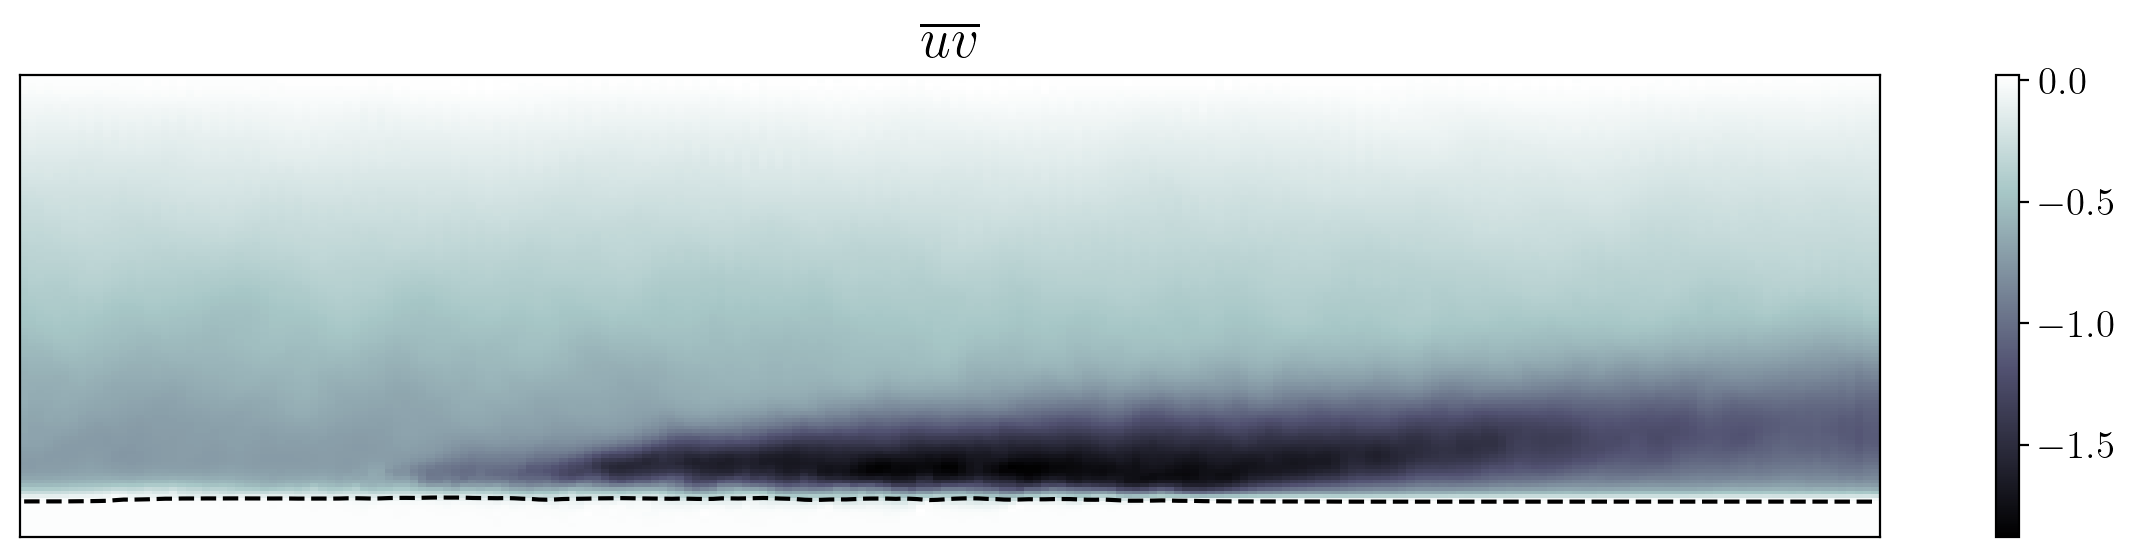

In [15]:
# Visualize by wall-normal Reynolds stress

X, Y = np.meshgrid(x, y)

# Include 99% isocontour of mean velocity
U_inf = 1
nu = 1/395  # Details in README-transition_bl.pdf
Re = (U_inf/nu)*x

plt.figure(figsize=(15, 3))
plt.pcolor(Re, y, Ruv, cmap='bone') #, vmin=0, vmax=1)
plt.colorbar()

plt.contour((U_inf/nu)*X, Y, u, [0.99], linestyles='dashed', colors='k')

plt.gca().set_yticks([])
plt.gca().set_xticks([])
plt.title(r'$\overline{uv}$')
plt.show()

In [16]:
dx = x[1]-x[0]
dy = y[1:]-y[:-1]

nx = len(x)
ny = len(y)

Dy = sparse.diags( [-1, 1], [-1, 1], shape=(ny, ny) ).toarray()
# Second-order forward/backwards at boundaries
Dy[0, :3] = np.array([-3, 4, -1])
Dy[-1, -3:] = np.array([1, -4, 3])
for i in range(ny-1):
    Dy[i, :] = Dy[i, :]/(2*dy[i])
Dy[-1, :] = Dy[-1, :]/(2*dy[-1])

# Repeat for each x-location
Dy = sparse.block_diag([Dy for i in range(nx)])

Dx = sparse.diags( [-1, 1], [-ny, ny], shape=(nx*ny, nx*ny))
Dx = sparse.lil_matrix(Dx)
# Second-order forwards/backwards at boundaries
for i in range(ny):
    Dx[i, i] = -3
    Dx[i, ny+i] = 4
    Dx[i, 2*ny+i] = -1
    Dx[-(i+1), -(i+1)] = 3
    Dx[-(i+1), -(ny+i+1)] = -4
    Dx[-(i+1), -(2*ny+i+1)] = 1
Dx = Dx/(2*dx)

Dx = sparse.csr_matrix(Dx)
Dy = sparse.csr_matrix(Dy)

Dxx = 2*(Dx @ Dx)
Dyy = 2*(Dy @ Dy)

In [32]:
u = u.flatten('F')
v = v.flatten('F')
p = p.flatten('F')
Ruu = Ruu.flatten('F')
Ruv = Ruv.flatten('F')
Duu = Duu.flatten('F')
Duv = Duv.flatten('F')

ux = Dx @ u
uy = Dy @ u
vx = Dx @ v
vy = Dy @ v
px = Dx @ p
py = Dy @ p
lap_u = (Dxx + Dyy) @ u
Ruux = Dx @ Ruu
Ruvy = Dy @ Ruv
Duux = Dx @ Duu
Duvy = Dy @ Duv

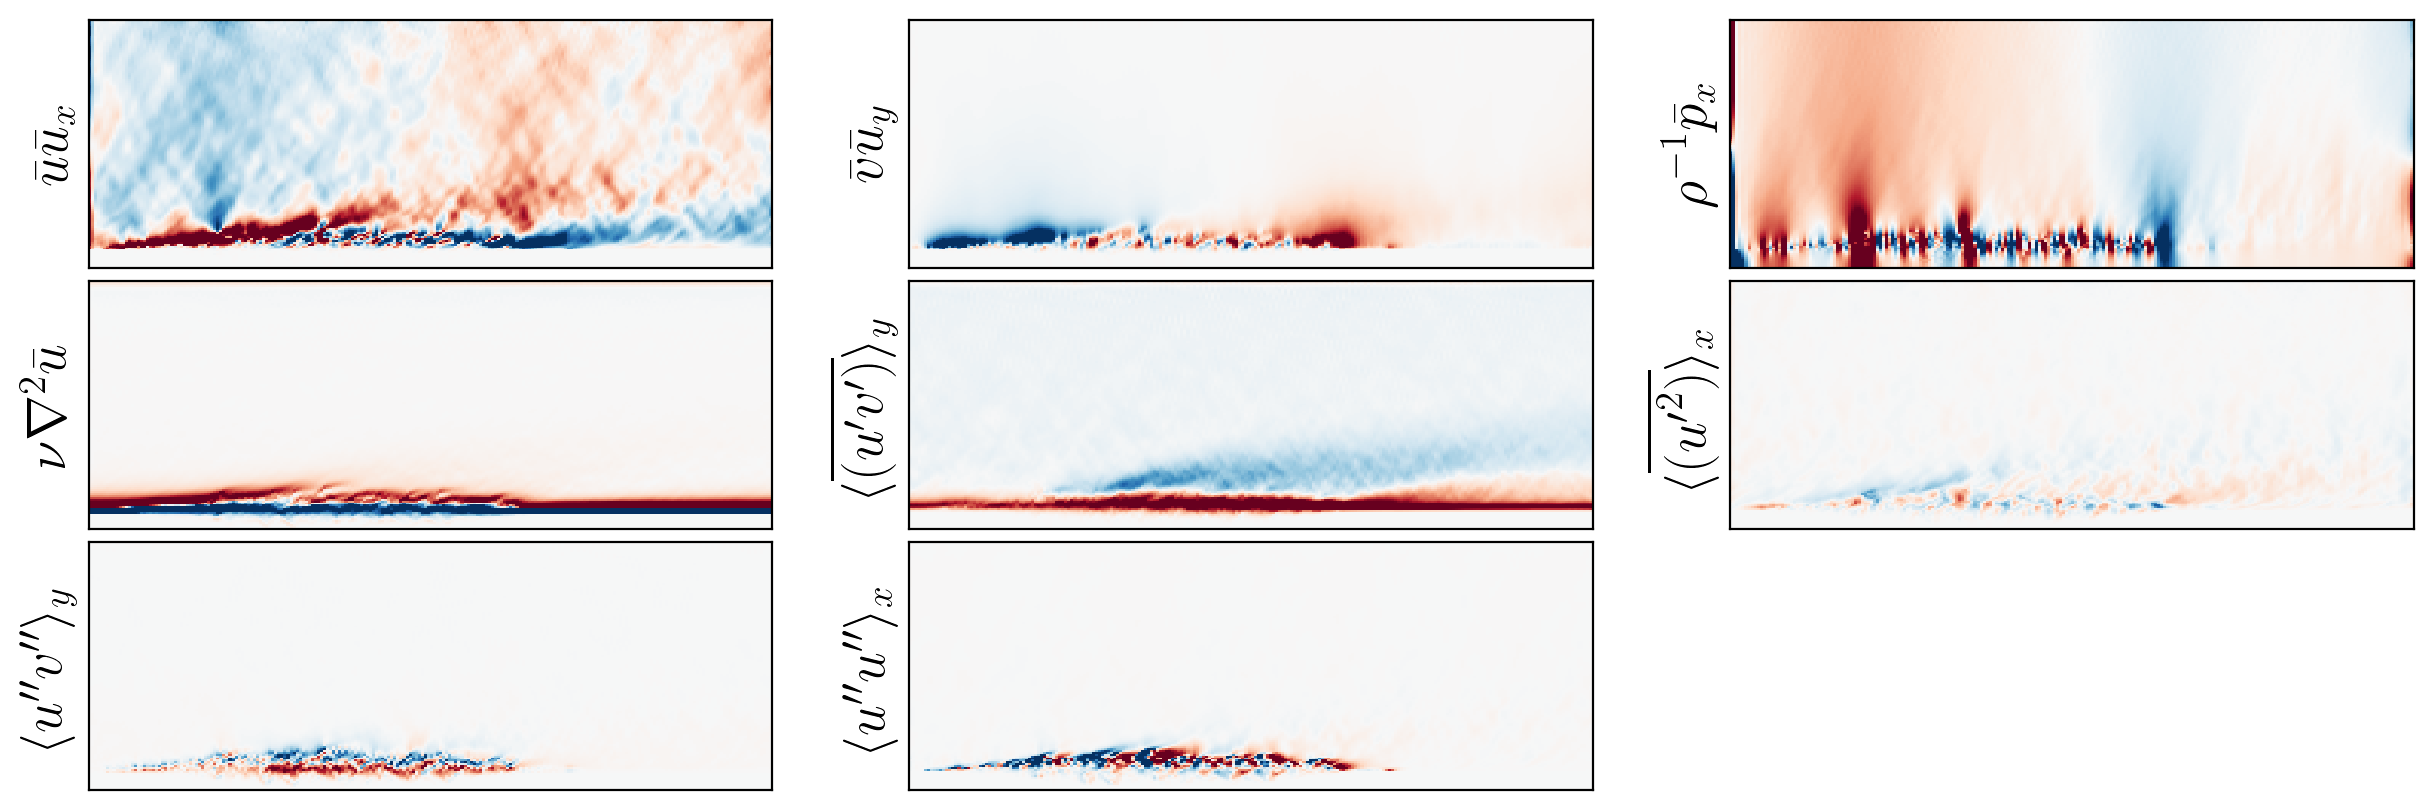

In [72]:
# Plot all six terms in the RANS equation
plt.figure(figsize=(15, 5))
labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$', r'$\rho^{-1} \bar{p}_x$',
          r'$\nu \nabla^2 \bar{u}$', r'$\langle\overline{(u^\prime v^\prime)}\rangle_y$', r'$\langle\overline{({u^\prime} ^2)}\rangle_x$',
          r'$\langle u^{\prime\prime} v^{\prime\prime}\rangle_y$', r'$\langle u^{\prime\prime} u^{\prime\prime}\rangle_x$']
clim = 20
fontsize=20

plt.subplot(331)
field = np.reshape(u*ux, [ny, nx], order='F')
plt.pcolor(x, y, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[0], fontsize=fontsize)

plt.subplot(332)
field = np.reshape(v*uy, [ny, nx], order='F')
plt.pcolor(x, y, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[1], fontsize=fontsize)

plt.subplot(333)
field = np.reshape(px, [ny, nx], order='F')
plt.pcolor(x, y, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[2], fontsize=fontsize)

plt.subplot(334)
field = np.reshape(nu*lap_u, [ny, nx], order='F')
plt.pcolor(x, y, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[3], fontsize=fontsize)

plt.subplot(335)
field = np.reshape(Ruvy, [ny, nx], order='F')
plt.pcolor(x, y, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[4], fontsize=fontsize)

plt.subplot(336)
field = np.reshape(Ruux, [ny, nx], order='F')
plt.pcolor(x, y, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[5], fontsize=fontsize)

plt.subplot(337)
field = np.reshape(Duvy, [ny, nx], order='F')
plt.pcolor(x, y, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[6], fontsize=fontsize)

plt.subplot(338)
field = np.reshape(Duux, [ny, nx], order='F')
plt.pcolor(x, y, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[7], fontsize=fontsize)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0.05)

plt.show()

In [45]:
# Train Gaussian mixture model

 # Advection, pressure, viscous, Reynolds stresses
features = 1*np.vstack([u*ux, v*uy, px, nu*lap_u, Ruvy, Ruux, Duvy, Duux]).T
nfeatures = features.shape[1]

# Fit Gaussian mixture model
nc = 8  # Number of clusters
seed = np.random.randint(2**32)
seed = 3696299933  #  Keep a seed for debugging/plotting
print(seed)
model = GaussianMixture(n_components=nc, random_state=seed)

# PERMUTATION
sample_pct = 1
mask = np.random.permutation(features.shape[0])[:int(sample_pct*features.shape[0])]
model.fit(features[mask, :])

3696299933


GaussianMixture(n_components=8, random_state=3696299933)

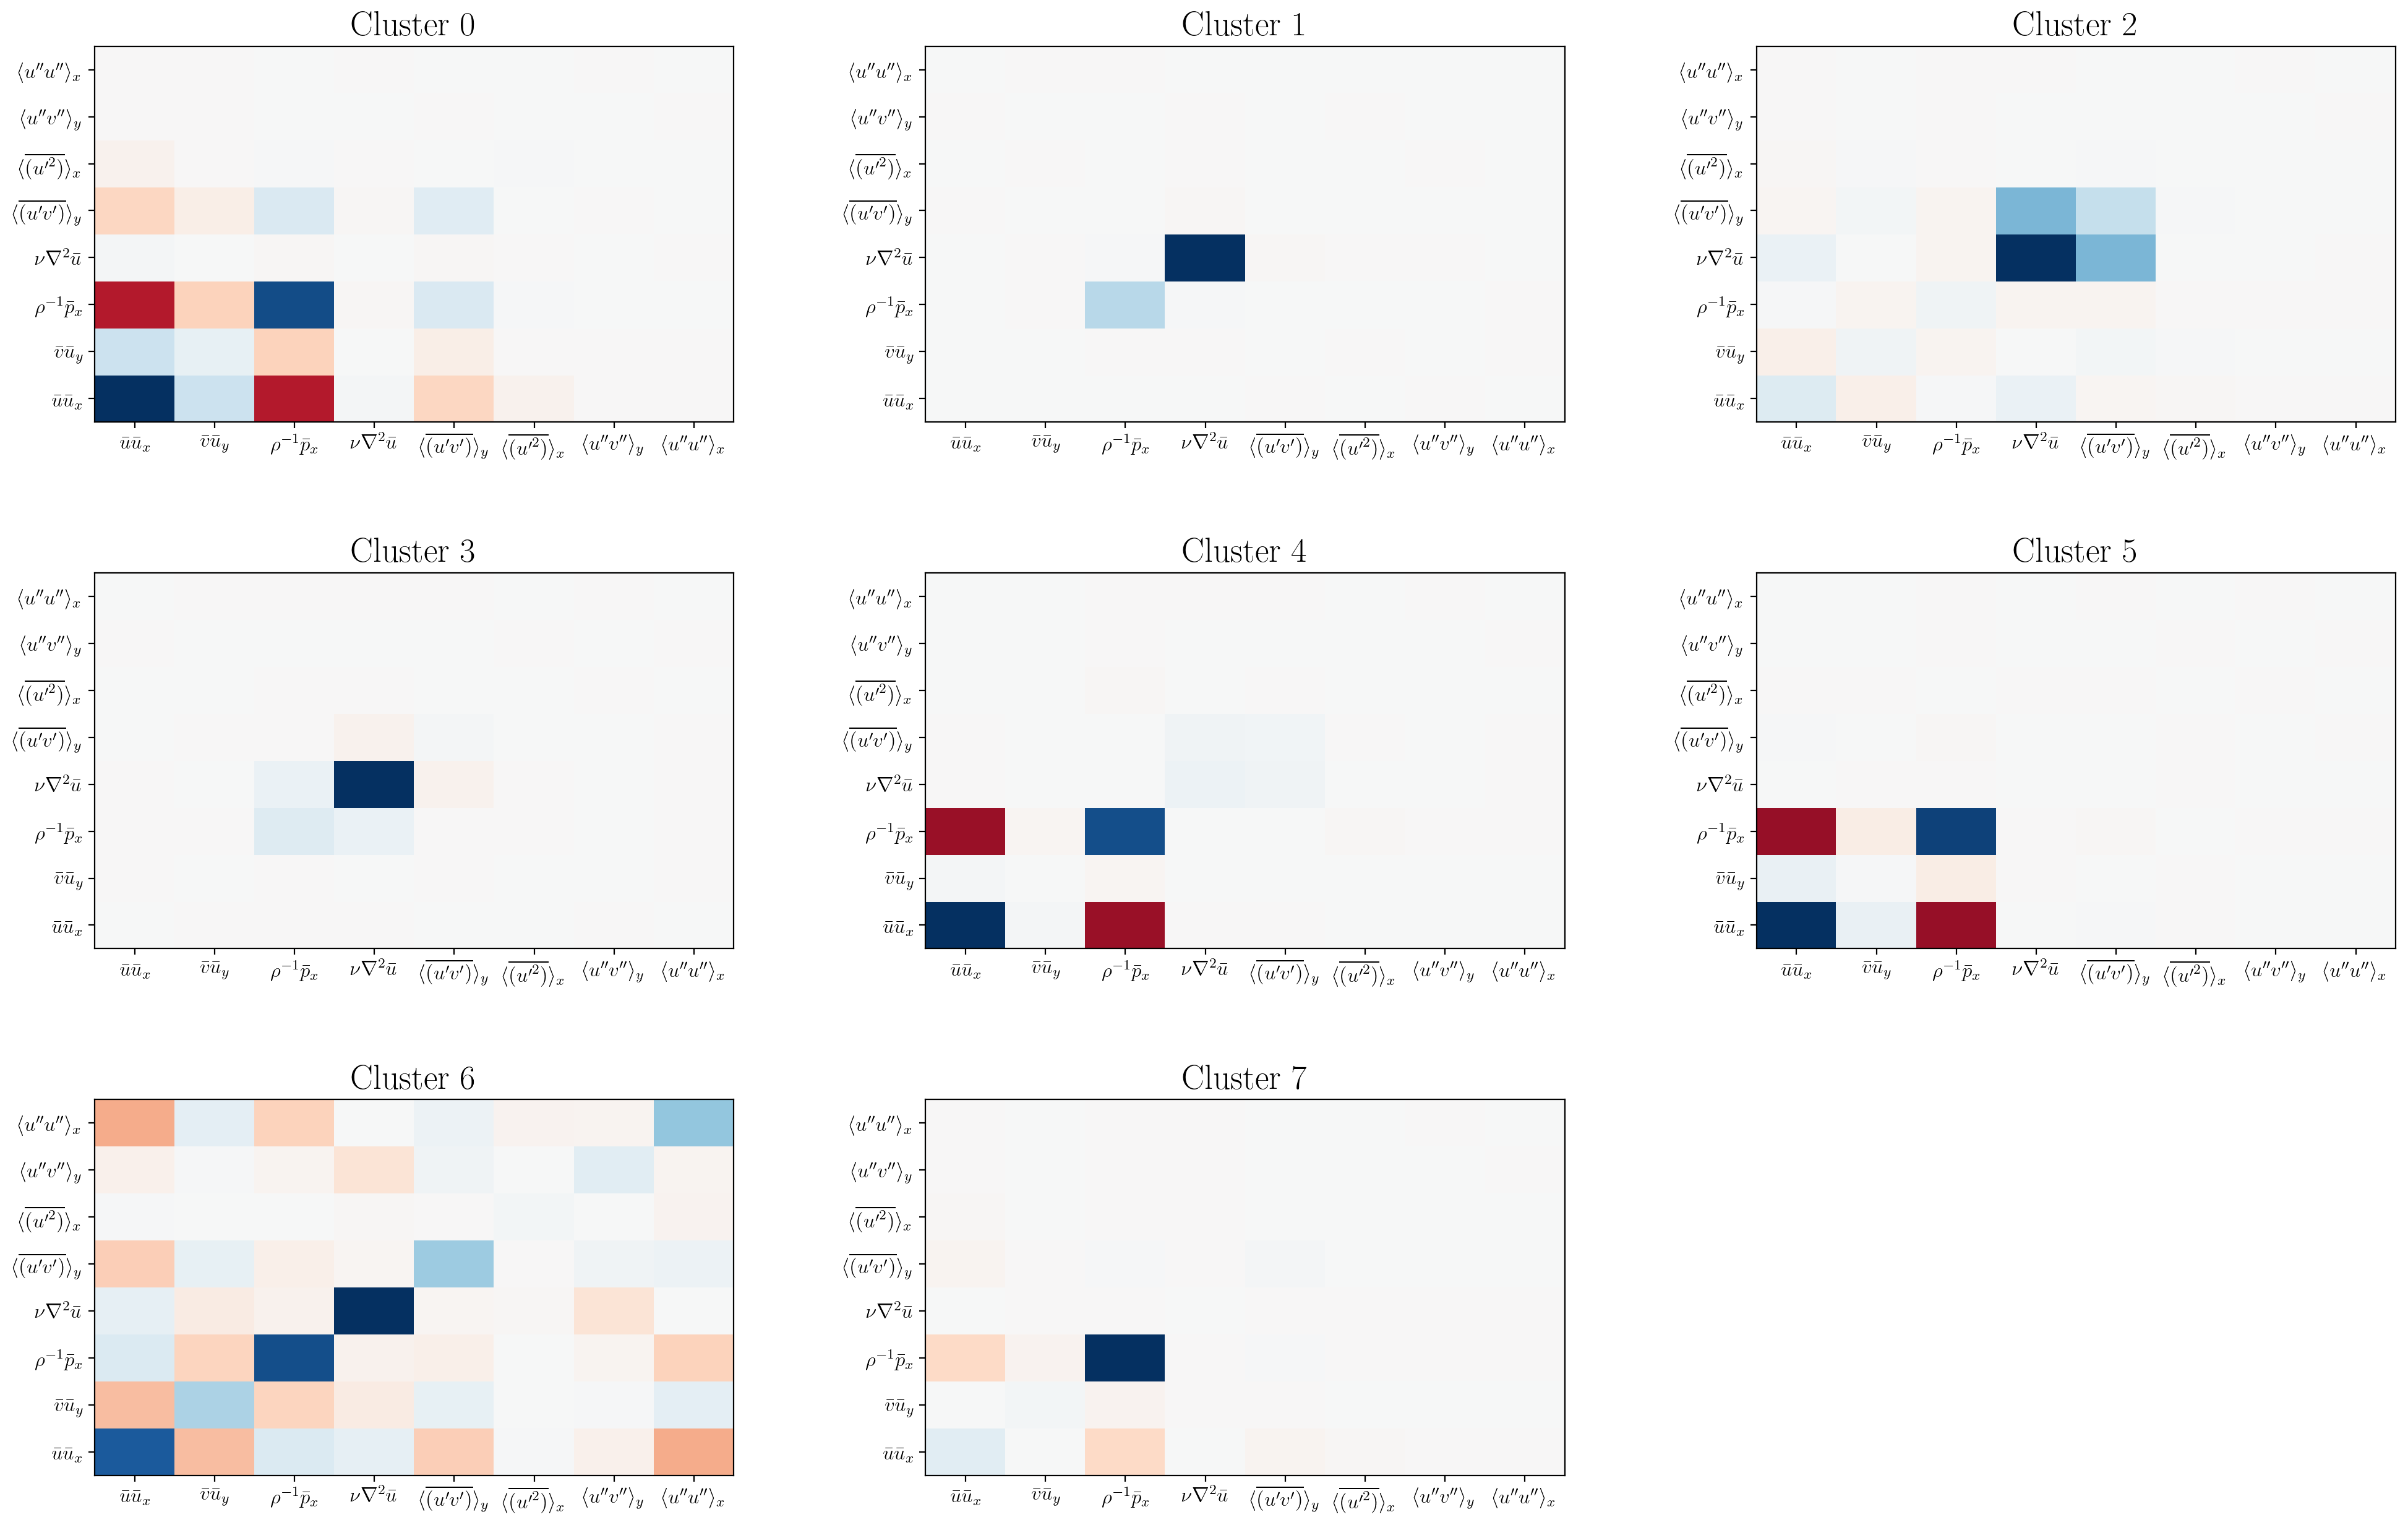

In [73]:
# Plot covariance matrices for the GMM
plt.figure(figsize=(24, 15))
for i in range(nc):
    plt.subplot(3, 3, i+1)
    C = model.covariances_[i, :, :]
    plt.pcolor(C, vmin=-max(abs(C.flatten())), vmax=max(abs(C.flatten())), cmap='RdBu')
    plt.gca().set_xticks(np.arange(0.5, nfeatures+0.5))
    plt.gca().set_xticklabels(labels, fontsize=12)
    plt.gca().set_yticks(np.arange(0.5, nfeatures+0.5))
    plt.gca().set_yticklabels(labels, fontsize=12)
    plt.gca().set_title('Cluster {0}'.format(i))

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.4)
plt.show()

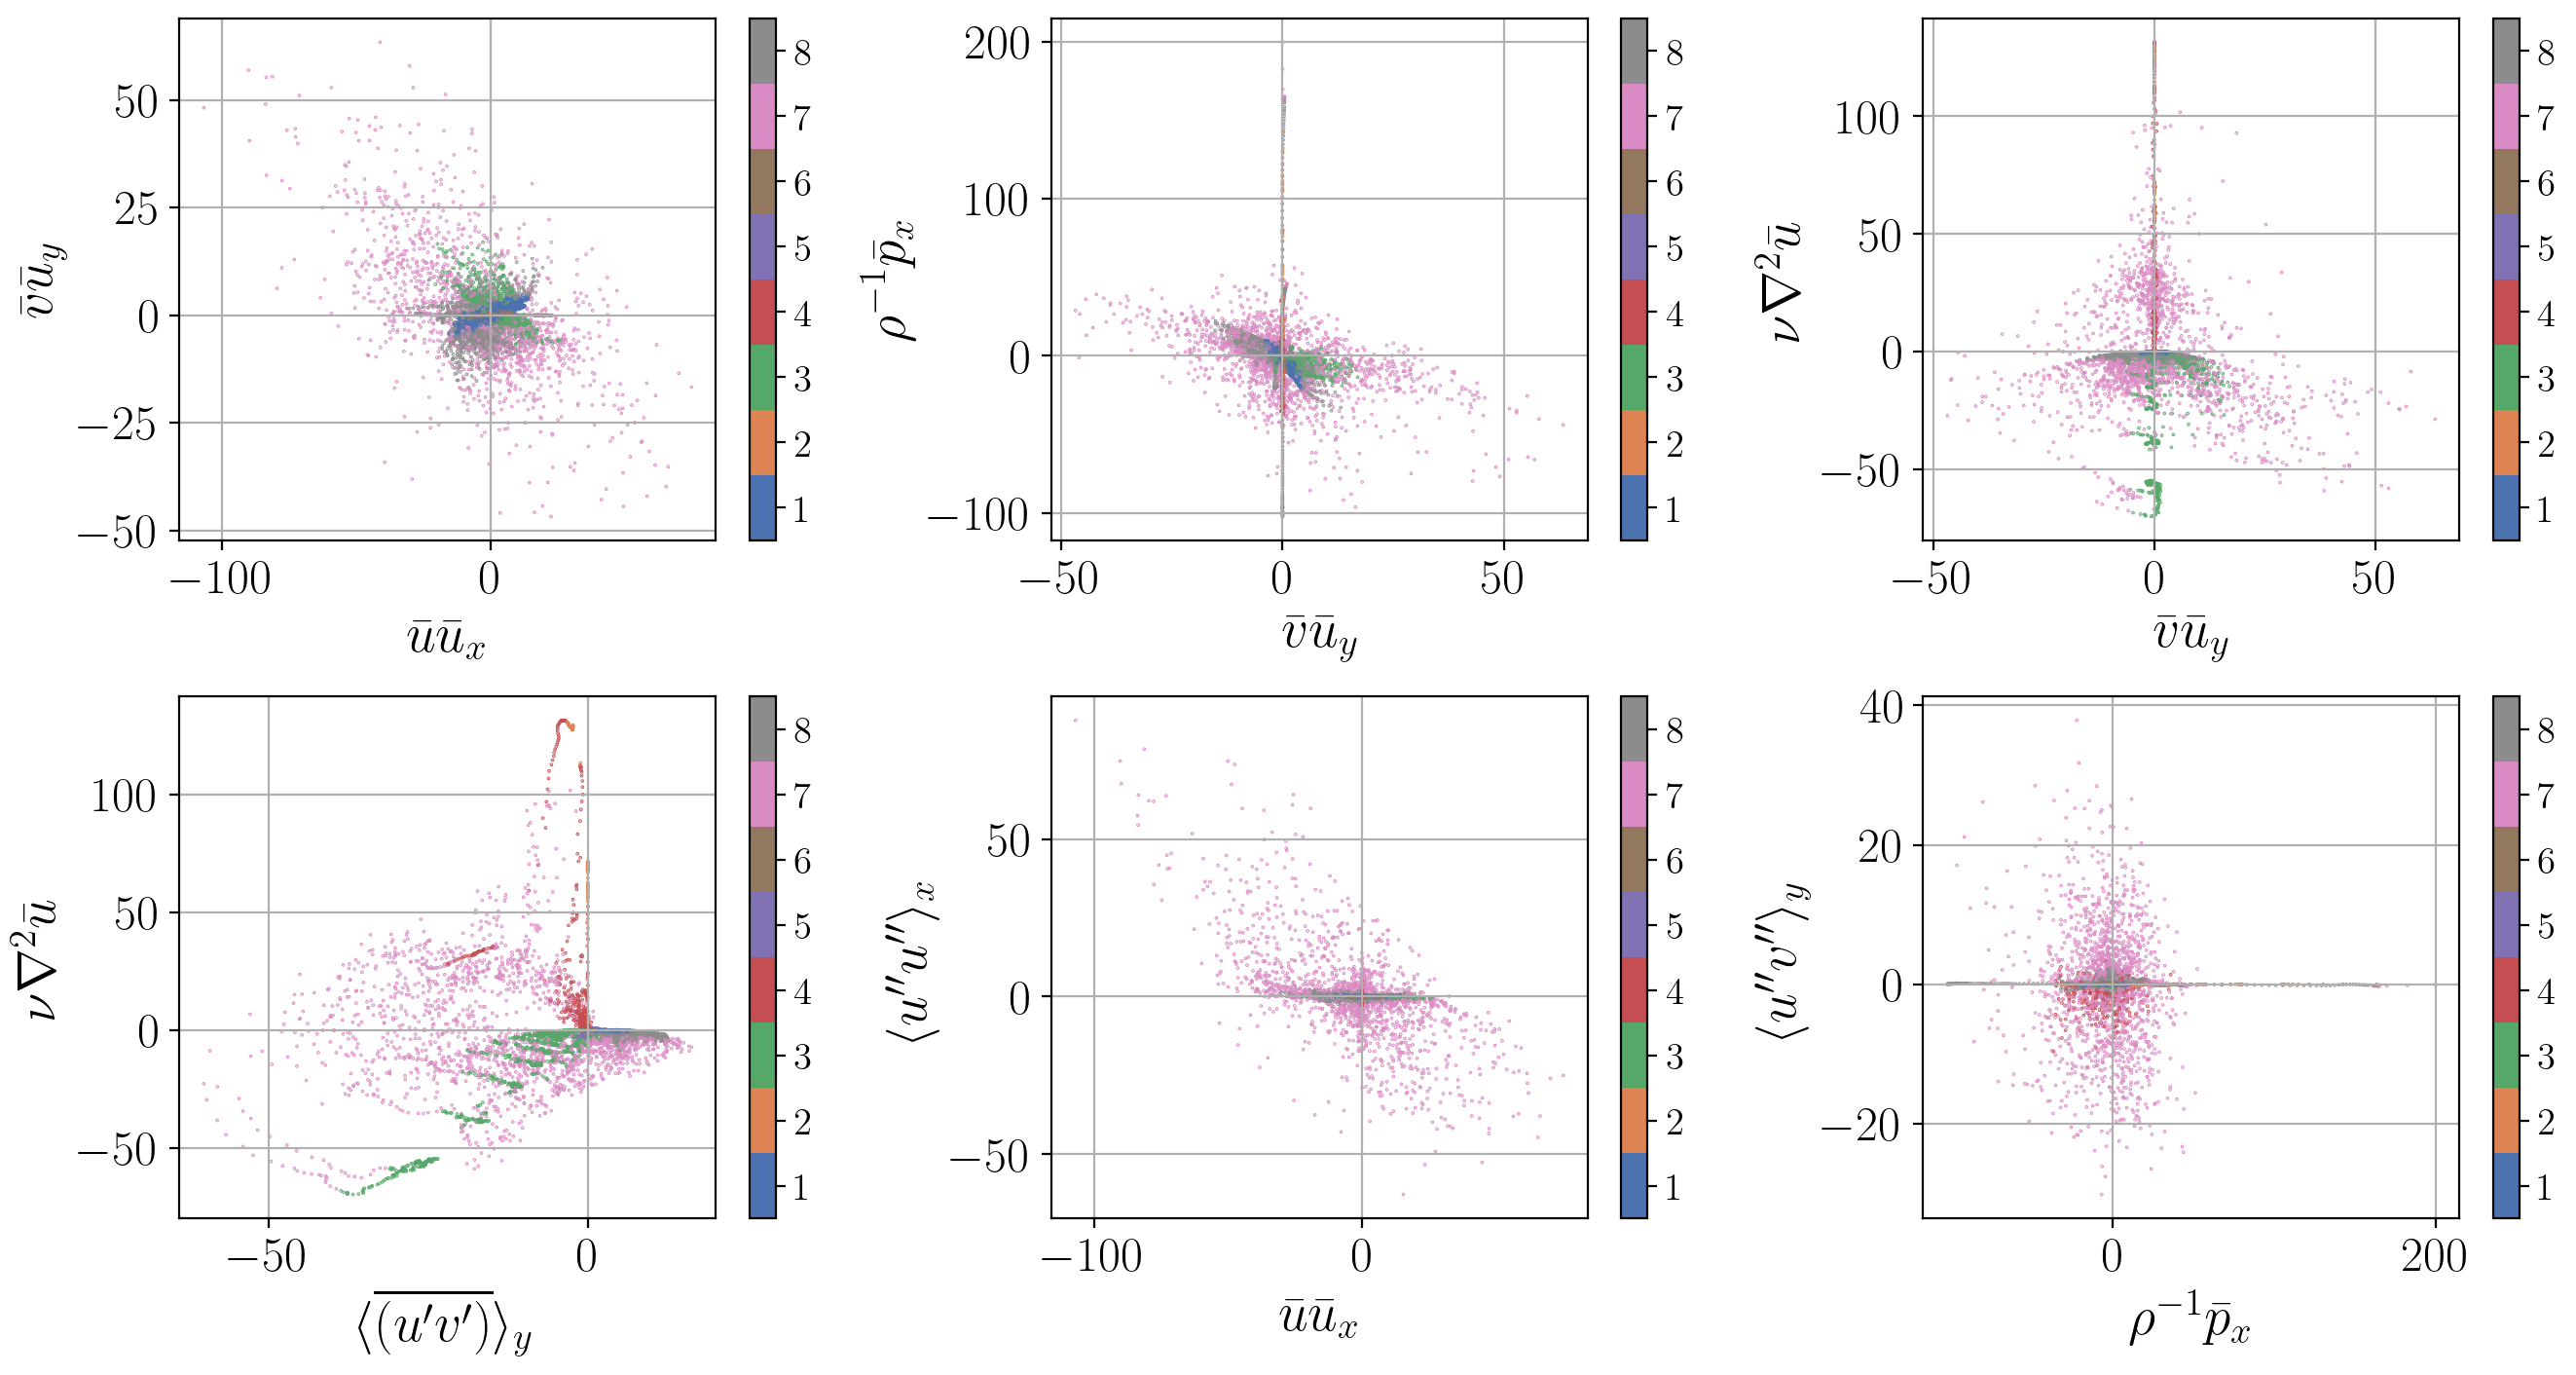

In [78]:
# Visualize GMM clustering with 2D views of equation space

cluster_idx = model.predict(features[mask, :])+1
clim = [.5, cm.N-0.5]
bounds = np.arange(0.5, nc+1.5)

plt.figure(figsize=(16, 8))
plt.subplot(231)
plt.scatter(features[mask, 0], features[mask,1], .1, cluster_idx, cmap=cm)
plt.xlabel(labels[0], fontsize=20)
plt.ylabel(labels[1], fontsize=20)
plt.clim([-.5, cm.N-0.5])
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(1, nc+1))
plt.grid()

plt.gca().tick_params(axis='both', which='major', labelsize=18)
plt.gca().tick_params(axis='both', which='minor', labelsize=18)

plt.subplot(232)
plt.scatter(features[mask, 1], features[mask,2], .1, cluster_idx, cmap=cm)
plt.xlabel(labels[1], fontsize=20)
plt.ylabel(labels[2], fontsize=20)
plt.clim([-.5, cm.N-0.5])
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(1, nc+1))
plt.grid()

plt.gca().tick_params(axis='both', which='major', labelsize=18)
plt.gca().tick_params(axis='both', which='minor', labelsize=18)


plt.subplot(233)
plt.scatter(features[mask, 1], features[mask,3], .1, cluster_idx, cmap=cm)
plt.xlabel(labels[1], fontsize=20)
plt.ylabel(labels[3], fontsize=20)
plt.clim([-.5, cm.N-0.5])
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(1, nc+1))
plt.grid()

plt.gca().tick_params(axis='both', which='major', labelsize=18)
plt.gca().tick_params(axis='both', which='minor', labelsize=18)


plt.subplot(234)
plt.scatter(features[mask, 4], features[mask,3], .1, cluster_idx, cmap=cm)
plt.xlabel(labels[4], fontsize=20)
plt.ylabel(labels[3], fontsize=20)
plt.clim([-.5, cm.N-0.5])
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(1, nc+1))
plt.grid()

plt.gca().tick_params(axis='both', which='major', labelsize=18)
plt.gca().tick_params(axis='both', which='minor', labelsize=18)


plt.subplot(235)
plt.scatter(features[mask, 0], features[mask,7], .1, cluster_idx, cmap=cm)
plt.xlabel(labels[0], fontsize=20)
plt.ylabel(labels[7], fontsize=20)
plt.clim([-.5, cm.N-0.5])
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(1, nc+1))
plt.grid()

plt.gca().tick_params(axis='both', which='major', labelsize=18)
plt.gca().tick_params(axis='both', which='minor', labelsize=18)

plt.subplot(236)
plt.scatter(features[mask, 2], features[mask,6], .1, cluster_idx, cmap=cm)
plt.xlabel(labels[2], fontsize=20)
plt.ylabel(labels[6], fontsize=20)
plt.clim([-.5, cm.N-0.5])
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(1, nc+1))
plt.grid()

plt.gca().tick_params(axis='both', which='major', labelsize=18)
plt.gca().tick_params(axis='both', which='minor', labelsize=18)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
plt.show()

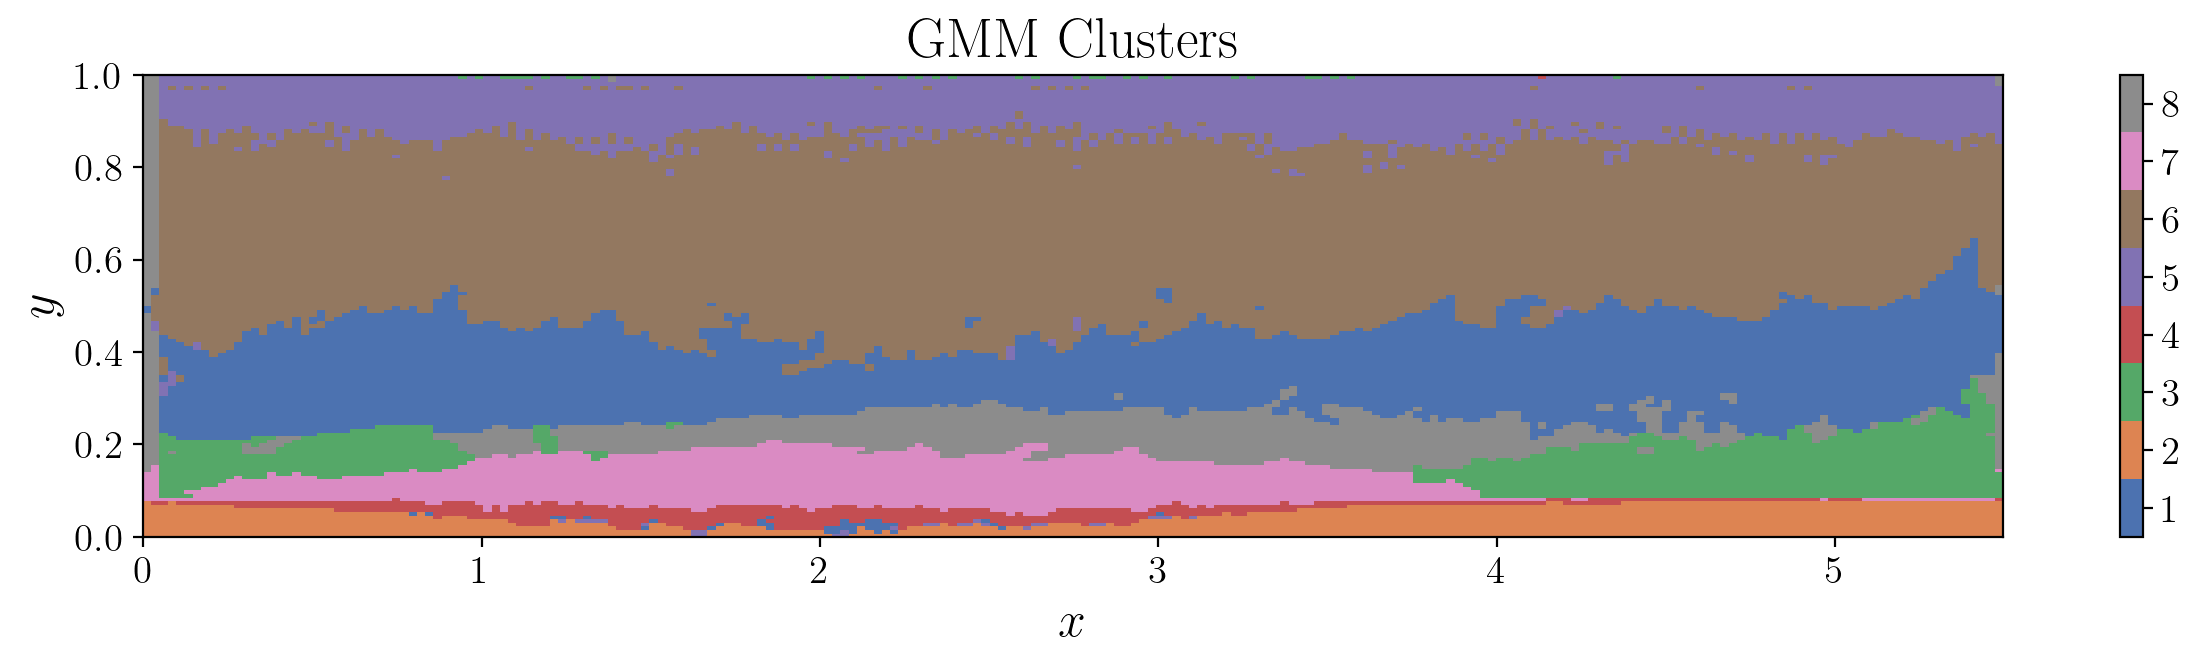

In [49]:
# "Predict" clusters in entire domain
cluster_idx = model.predict(features)
clustermap = np.reshape(cluster_idx, [ny, nx], order='F')

# Colormap of clusters in entire domain
plt.figure(figsize=(15, 3))
plt.pcolor(x, y, clustermap+1, cmap=cm, vmin=-0.5, vmax=cm.N-0.5)
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(0, nc+1))

#plt.contour(X, Y, np.reshape(u/U_inf, [ny, nx], order='F'), [0.99], linestyles='dashed', colors='k')

plt.xlabel('$x$', fontsize=18)
plt.ylabel('$y$', fontsize=18)
plt.title('GMM Clusters', fontsize=20)

plt.show()

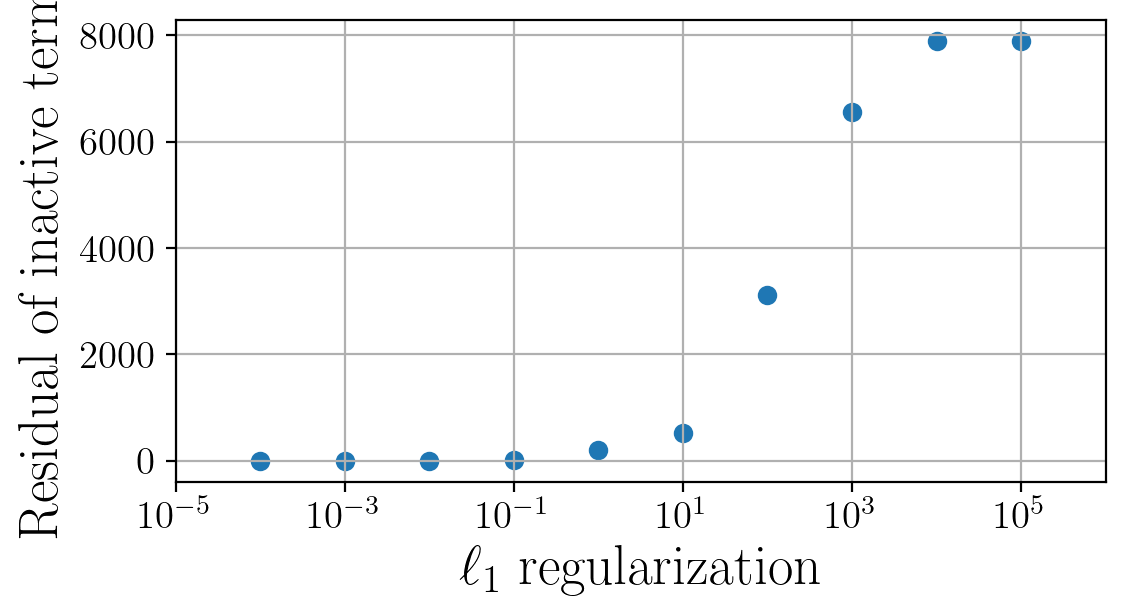

In [50]:
# Sparse PCA to identify directions of nonzero variance
#   First step: model selection for L1 regularization
alphas = [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1e3, 1e4, 1e5]
err = np.zeros([len(alphas)])  # Error defined as norm of inactive terms
sparsity = np.zeros([len(alphas)])

for k in range(len(alphas)):
    for i in range(nc):
        # Identify points in the field corresponding to each cluster
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alphas[k])
        spca.fit(cluster_features)
        active_terms = np.nonzero(spca.components_[0])[0]
        inactive_terms = [feat for feat in range(nfeatures) if feat not in active_terms ]

        err[k] += np.linalg.norm(cluster_features[:, inactive_terms])

plt.figure(figsize=(6, 3))
plt.scatter(alphas, err)
plt.xlabel(r'$\ell_1$ regularization')
plt.ylabel('Residual of inactive terms')
plt.gca().set_xscale('log')
plt.xlim([1e-5, 1e6])
plt.grid()
plt.show()

In [61]:
# Sparse PCA to identify directions of nonzero variance
alpha_opt = 10

spca_model = np.zeros([nc, nfeatures])
for i in range(nc):
    feature_idx = np.nonzero(cluster_idx==i)[0]
    cluster_features = features[feature_idx, :]
    spca = SparsePCA(n_components=1, alpha=alpha_opt)
    spca.fit(cluster_features)
    print('GMM Cluster {0}:'.format(i))
    active_terms = np.nonzero(spca.components_[0])[0]
    if len(active_terms)>0:
        print([labels[k] for k in active_terms])
        spca_model[i, active_terms] = 1  # Set to 1 for active terms in model
    else: print('None')

GMM Cluster 0:
['$\\bar{u} \\bar{u}_x$', '$\\bar{v}\\bar{u}_y$', '$\\rho^{-1} \\bar{p}_x$', '$\\overline{(u^\\prime v^\\prime)}_y$', '$\\overline{({u^\\prime} ^2)}_x$']
GMM Cluster 1:
['$\\rho^{-1} \\bar{p}_x$', '$\\nu \\nabla^2 \\bar{u}$', '$\\overline{(u^\\prime v^\\prime)}_y$']
GMM Cluster 2:
['$\\bar{u} \\bar{u}_x$', '$\\rho^{-1} \\bar{p}_x$', '$\\nu \\nabla^2 \\bar{u}$', '$\\overline{(u^\\prime v^\\prime)}_y$']
GMM Cluster 3:
['$\\rho^{-1} \\bar{p}_x$', '$\\nu \\nabla^2 \\bar{u}$', '$\\overline{(u^\\prime v^\\prime)}_y$']
GMM Cluster 4:
['$\\bar{u} \\bar{u}_x$', '$\\rho^{-1} \\bar{p}_x$']
GMM Cluster 5:
['$\\bar{u} \\bar{u}_x$', '$\\bar{v}\\bar{u}_y$', '$\\rho^{-1} \\bar{p}_x$']
GMM Cluster 6:
['$\\bar{u} \\bar{u}_x$', '$\\bar{v}\\bar{u}_y$', '$\\rho^{-1} \\bar{p}_x$', '$\\nu \\nabla^2 \\bar{u}$', '$\\overline{(u^\\prime v^\\prime)}_y$', '$\\overline{({u^\\prime} ^2)}_x$', '$<(u^{\\prime\\prime} v^{\\prime\\prime})>_y$', '$<(u^{\\prime\\prime} u^{\\prime\\prime})>_x$']
GMM Cluster

In [62]:
balance_models, model_index = np.unique(spca_model, axis=0, return_inverse=True)
nmodels = balance_models.shape[0]
print(balance_models)

for i in range(nmodels):
    print('SPCA Cluster {0}:'.format(i))
    active_terms = np.nonzero(balance_models[i, :])[0]
    if len(active_terms)>0:
        print([labels[k] for k in active_terms])
    else: print('No dynamics')

# Make new cluster_idx based on SPCA balance model
balance_idx = np.array([model_index[i] for i in cluster_idx])
balancemap = np.reshape(balance_idx, [ny, nx], order='F')

[[0. 0. 1. 1. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 1. 0. 0. 0.]
 [1. 1. 1. 0. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]
SPCA Cluster 0:
['$\\rho^{-1} \\bar{p}_x$', '$\\nu \\nabla^2 \\bar{u}$', '$\\overline{(u^\\prime v^\\prime)}_y$']
SPCA Cluster 1:
['$\\bar{u} \\bar{u}_x$', '$\\rho^{-1} \\bar{p}_x$']
SPCA Cluster 2:
['$\\bar{u} \\bar{u}_x$', '$\\rho^{-1} \\bar{p}_x$', '$\\nu \\nabla^2 \\bar{u}$', '$\\overline{(u^\\prime v^\\prime)}_y$']
SPCA Cluster 3:
['$\\bar{u} \\bar{u}_x$', '$\\bar{v}\\bar{u}_y$', '$\\rho^{-1} \\bar{p}_x$']
SPCA Cluster 4:
['$\\bar{u} \\bar{u}_x$', '$\\bar{v}\\bar{u}_y$', '$\\rho^{-1} \\bar{p}_x$', '$\\overline{(u^\\prime v^\\prime)}_y$']
SPCA Cluster 5:
['$\\bar{u} \\bar{u}_x$', '$\\bar{v}\\bar{u}_y$', '$\\rho^{-1} \\bar{p}_x$', '$\\overline{(u^\\prime v^\\prime)}_y$', '$\\overline{({u^\\prime} ^2)}_x$']
SPCA Cluster 6:
['$\\bar{u} \\bar{u}_x$', '$\\bar{v}\\bar{u}_y$', '$\\rho^{-1} \\bar{p}_x$'

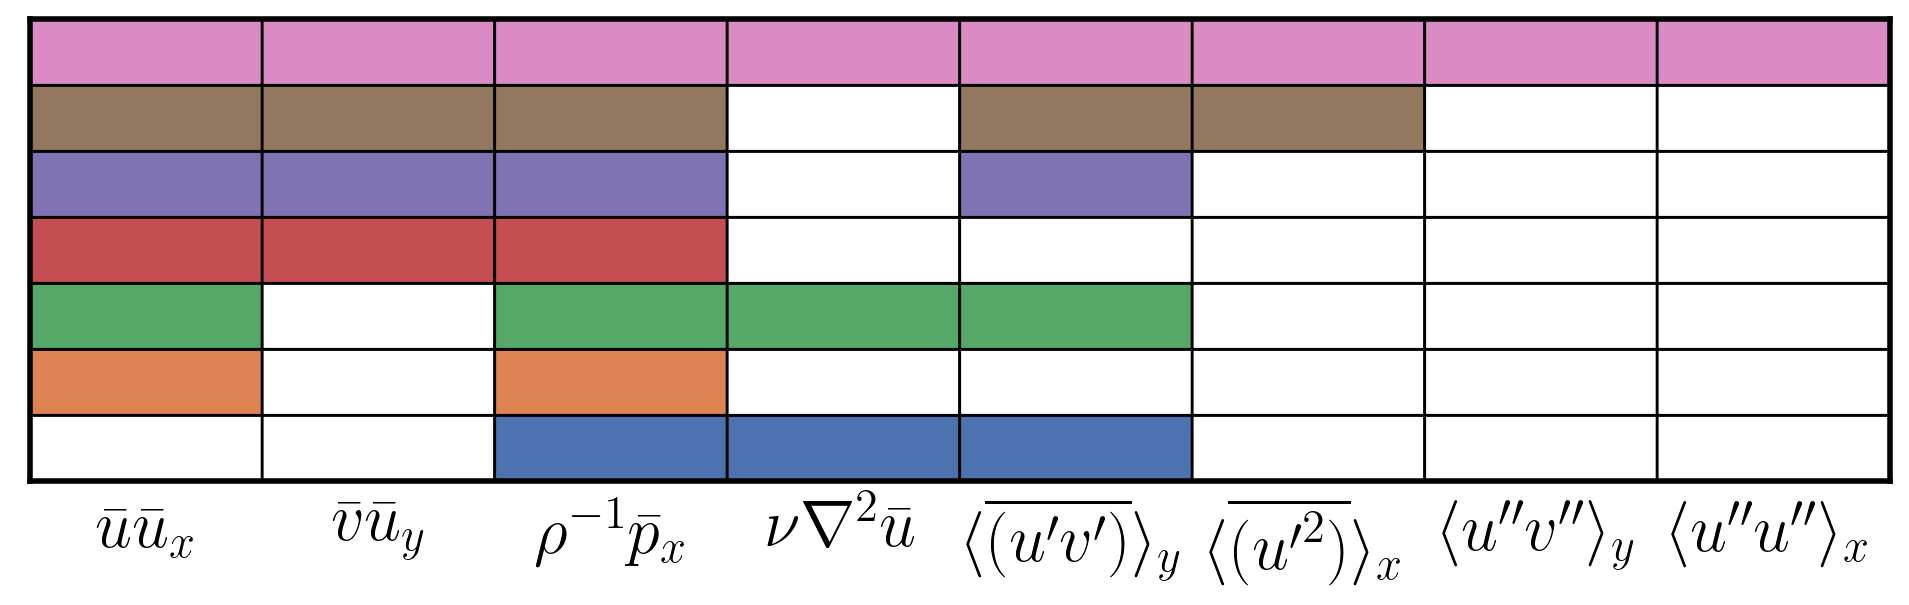

In [74]:
# Plot a grid with active terms in each cluster
gridmap = balance_models.copy()
gridmask = gridmap==0
gridmap = (gridmap.T*np.arange(nmodels)).T+1  # Scale map so that active terms can be color-coded
gridmap[gridmask] = 0

# Delete zero terms
grid_mask = np.nonzero( np.all(gridmap==0, axis=0) )[0]
gridmap = np.delete(gridmap, grid_mask, axis=1)
grid_labels = np.delete(labels, grid_mask)

plt.figure(figsize=(12, 3))
plt.pcolor(gridmap, vmin=-0.5, vmax=cm.N-0.5, cmap=cm, edgecolors='k', linewidth=1)
#plt.gca().set_xticks(np.arange(0.5, gridmap.shape[0]+0.5))
plt.gca().set_xticks(np.arange(0.5, gridmap.shape[1]+0.5))
plt.gca().set_xticklabels(grid_labels, fontsize=24)
plt.gca().set_yticklabels([])
#plt.gca().set_yticks(np.arange(0.5, nmodels+0.5))
#plt.gca().set_yticklabels(range(nc), fontsize=20
#plt.ylabel('Balance Model')

for axis in ['top','bottom','left','right']:
    plt.gca().spines[axis].set_linewidth(2)

plt.gca().tick_params(axis='both', width=0)
plt.show()

In [67]:
gridmap.shape

(7, 8)

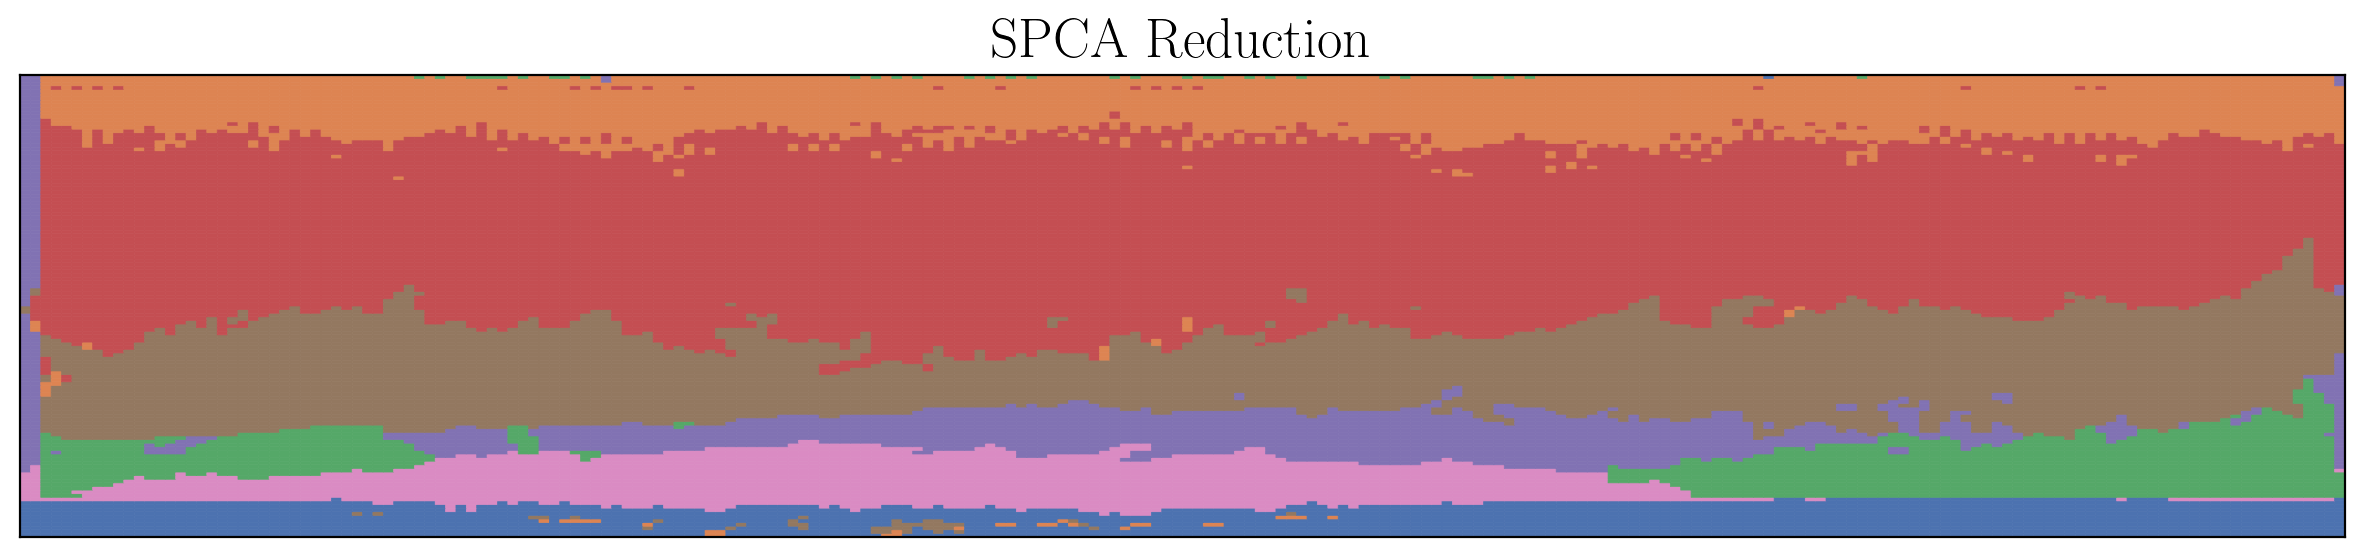

In [54]:
plt.figure(figsize=(15, 3))
plt.pcolor(x, y, balancemap+1, cmap=cm, vmin=-0.5, vmax=cm.N-0.5, alpha=1, edgecolors='face')

plt.gca().set_xticks([])
plt.gca().set_yticks([])

#plt.xlabel('$x$')
#plt.ylabel('$y$')
plt.title('SPCA Reduction')

plt.show()